In [ ]:
!pip install -q pyomo
!apt-get install -y -qq coinor-cbc


In [244]:
from pyomo.environ import *

from collections import namedtuple
import math,random
import numpy as np
from sklearn.neighbors import KDTree
import pandas as pd


Point = namedtuple("Point", ['x', 'y'])
Facility = namedtuple("Facility", ['index', 'setup_cost', 'capacity','location'])
Customer = namedtuple("Customer", ['index', 'demand','location'])

with open('./fl_100_1', 'r') as input_data_file:
            input_data = input_data_file.read()

#def solve_it(input_data):
if True:
    # Modify this code to run your optimization algorithm

    # parse the input
    lines = input_data.split('\n')

    parts = lines[0].split()
    facility_count = int(parts[0])
    customer_count = int(parts[1])

    facilities = []
    for i in range(1, facility_count+1):
        parts = lines[i].split()
        facilities.append(Facility(i-1, float(parts[0]), int(parts[1]), Point(float(parts[2]), float(parts[3])) ))

    customers = []
    for i in range(facility_count+1, facility_count+1+customer_count):
        parts = lines[i].split()
        customers.append(Customer(i-1-facility_count, int(parts[0]), Point(float(parts[1]), float(parts[2]))))

df_fac = pd.DataFrame(facilities)
df_cust= pd.DataFrame(customers)

df_cust['x'] = df_cust['location'].apply(lambda p : p.x)
df_cust['y'] = df_cust['location'].apply(lambda p : p.y)
df_fac['x'] = df_fac['location'].apply(lambda p : p.x)
df_fac['y'] = df_fac['location'].apply(lambda p : p.y)
df_fac['demand'] = 0
df_cust['assigned'] = -999


N = len(df_fac)
M = len(df_cust)
P = 3
d = np.sum((np.expand_dims(df_fac[['x','y']].values,1) - np.expand_dims(df_cust[['x','y']].values,0))**2,-1)**.5



model = ConcreteModel()
model.Locations = list(range(N))
model.Customers = list(range(M))
model.x = Var( model.Locations, model.Customers,within=Binary  ) #discrete, facilty,cust matrix
model.y = Var( model.Locations, within=Binary ) #facility is open/closed

model.obj = Objective( expr = sum( d[n,m]*model.x[n,m] for n in model.Locations for m in model.Customers )\
                      + sum([model.y[n]*c for n,c in zip(model.Locations,df_fac['setup_cost'])]),
                      sense=minimize )
model.single_x = ConstraintList()
for m in model.Customers:
    model.single_x.add(sum( model.x[n,m] for n in model.Locations ) == 1.0 )
model.bound_y = ConstraintList()
for n in model.Locations:
    for m in model.Customers:
        model.bound_y.add( model.x[n,m] <= model.y[n] )

for n in model.Locations:
      model.bound_y.add( sum([ d*model.x[n,m] for m,d in zip(model.Customers,df_cust['demand']) ]) <=df_fac.loc[n,'capacity'] )
model.num_facilities = Constraint(expr=sum( model.y[n] for n in model.Locations ) == 7 )

#model.pprint()
SolverFactory('cbc', executable='/usr/bin/cbc').solve(model).write()


solution = np.argmax(np.reshape(model.x[:,:](),(N,M)),0)

# for n in range(N):
#     assign = np.argwhere(solution==n)[:,0]
#     x_fac,y_fac = df_fac.loc[n,['x','y']]
#     if len(assign)>0:
#         for x,y,idx in df_cust.loc[assign,['x','y','index']].values:
#             plt.plot([x,x_fac],[y,y_fac],'b')
#             plt.plot([x],[y],'bo')
#             plt.text(x,y,str(idx))
#         plt.plot([x_fac],[y_fac],'ro')
#         plt.text(x_fac,y_fac,str(n))


N,M,np.array(solution)

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 22724065.88632476
  Upper bound: 22724065.88632476
  Number of objectives: 1
  Number of constraints: 101101
  Number of variables: 100100
  Number of binary variables: 100100
  Number of integer variables: 100100
  Number of nonzeros: 100100
  Sense: minimize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 203.21
  Wallclock time: 211.88
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution i

(100,
 1000,
 array([19, 68, 64, 56, 64, 34, 51, 51, 51, 68, 19, 64, 19, 64, 51, 68, 34,
        51, 64, 68, 51, 51, 56, 64, 51, 51, 68, 51, 34, 51, 56, 68, 19, 19,
        48, 48, 48, 56, 51, 51, 48, 19, 64, 56, 56, 51, 51, 19, 48, 56, 51,
        64, 51, 51, 64, 64, 51, 19, 19, 51, 64, 56, 68, 34, 51, 19, 51, 48,
        51, 19, 51, 34, 51, 64, 48, 51, 68, 34, 51, 64, 34, 19, 34, 19, 51,
        56, 56, 56, 48, 51, 51, 34, 64, 19, 19, 19, 56, 51, 64, 51, 64, 19,
        51, 68, 51, 51, 19, 68, 68, 19, 64, 51, 51, 56, 51, 48, 51, 68, 51,
        64, 68, 51, 51, 56, 64, 19, 56, 48, 51, 51, 48, 56, 51, 51, 51, 34,
        51, 48, 48, 19, 51, 56, 51, 56, 68, 68, 68, 51, 64, 51, 68, 51, 51,
        34, 51, 19, 51, 51, 51, 51, 51, 51, 51, 48, 68, 64, 34, 19, 64, 51,
        48, 48, 51, 19, 34, 51, 51, 56, 34, 64, 48, 34, 64, 56, 51, 19, 51,
        68, 34, 56, 51, 48, 68, 68, 51, 51, 51, 34, 51, 51, 51, 51, 19, 51,
        68, 56, 64, 48, 51, 34, 51, 19, 51, 51, 64, 68, 64, 19, 19, 68, 68,

In [261]:
from pyomo.environ import *

from collections import namedtuple
import math,random
import numpy as np
from sklearn.neighbors import KDTree
import pandas as pd

sln = [155,   0, 132,  66,  76,  33, 116, 120,   6, 161, 167,  19,  35,
         98, 136, 183,  99, 127,  35,  46,  60,  85, 139, 192, 167,   9,
         95, 118,  51, 151,  68, 180,  72, 175,   3,  28, 149, 157, 120,
        199, 108,  49, 151, 175, 171,  35, 114,   9, 123,  30, 133,  18,
          4, 157,  90,  99, 151,   3, 160, 118, 183, 167,   3,  26,  51,
         37,  25,  25,  90, 198,  18, 162, 146,  86,  60, 118, 101,  70,
        159,  30, 123, 132,  57,  92,  37,  71, 146,  34,   2, 180,  18,
         30, 139,  98,  85,  33, 141,  94, 162,  90, 113, 108, 149, 119,
         46, 118, 175, 192, 140, 173, 144,  99,  34, 120, 101,  30, 165,
         33, 139,  69,  37,  32, 179, 134,   0, 171, 180, 192,   6, 197,
         66,   6,  76,   4, 123, 155,  98,  66,  49,  18, 105,  60, 136,
        133,  69,  32, 140, 146, 119,   4, 127,  92, 197, 160,   0, 113,
        176,  22, 146, 146,  32, 101, 160, 123, 118,  32, 121,   9, 105,
        123, 151, 135, 146,  85,  49,  32,  22, 179,  45,  95, 167,   9,
         60,  94, 199, 139, 177, 177, 151, 151, 118,  26, 178,  60,  49,
         26,  35, 100, 179, 123, 144,  68,   9, 119, 176, 183, 136,  86,
         19, 173, 121, 114,  28,  25,  68,  94,   4, 132, 165, 116,  92,
         72, 175,  28,  99,  34, 165, 134, 175, 186,  55, 177,  32,   2,
        160, 114,  99,   6,  90, 159, 136, 133, 123, 118, 167,  37, 100,
         95, 100, 105, 197,  45, 151,  35,  45, 133, 134, 134, 172,  90,
         89,   9,   7, 152, 101,  28, 186, 144, 133,  30, 198,  85, 126,
        153, 126, 173,   4,  98,  19, 132, 108, 160, 137, 161,  71,  45,
        127,   2, 100, 116, 113, 123, 162, 114,  37,   0, 157, 167, 189,
        152, 151,  70, 180,  94, 113,  52, 159,  46,  70,  76,  18, 120,
        175,  26, 189, 197,  26, 127, 157, 137,  28, 199, 179, 127, 116,
        199, 101,  86, 135, 141, 116, 120, 118, 198, 159,  22,  25,  51,
         30,  35, 144,  22, 134, 178, 114,  71,  70,  89, 161,   3,  19,
         69, 171, 168,  69, 179,  85, 135, 108,  35,  90, 141,  25,  89,
        126, 183, 126, 116, 171,  79,  51, 189,  34, 101, 197,  92,  70,
         68,  92,  79,   0,  71, 116, 100,  66,  57, 165, 119, 153,  69,
         51, 157, 133,  89,   0, 178, 161, 180,  98, 178,  76, 140,  90,
         45,  35, 180, 137,  79, 105, 192, 151,  79, 175, 183, 162,  94,
        127, 113, 189, 178, 139,  92,   9, 120,   0, 159,  70, 198, 197,
        151, 116, 120, 155, 144,  68,  71,  69,  52, 153, 159, 186, 188,
          6,   3, 159,   7, 188,  57,  57,  60,  18,  99,   7,  37,  52,
        183,  19, 173, 157,  26, 188,  34,   7,  34, 132, 173,  22, 159,
        167, 136, 136, 127, 137,  26,  46, 152,  25,  25,  22,  71, 141,
        126,  70, 144, 101, 113, 114, 144,  68, 137, 113,  89, 171,  30,
        141, 133, 135, 146,   3, 172, 132, 186,  46, 144, 186,  52,  69,
        119,   0, 188, 149, 144,  45,  89,  45, 176, 192, 197, 162,  95,
        100, 160, 114,  22, 175,   7, 188, 123, 180,   9,  19, 119, 178,
          3, 144,   9, 159,   7,  45, 186, 144, 123,  70, 177, 168, 173,
         71, 140, 120,  60,  60, 160, 159,  71, 192, 177,   2, 167,  70,
        127, 139, 135, 161, 186, 173,  86,   6, 108,  92, 146,  94,  66,
        101,  34,  55,  32,  92, 176,  95,  34,  72, 168, 135,   2,  68,
        149, 198, 180, 186, 137,  28, 160, 179,  89, 172, 176, 140, 101,
        146, 127, 157, 114, 160, 139, 114, 183,  94,  66, 197, 188,  46,
        171, 183, 183, 157,   3, 119, 141, 108, 108, 171,  72,   7,  98,
         33,   6,  33,  95,   4, 177,  32, 192,   3, 165,  26,   0, 135,
         95, 101, 134, 179,  72, 149, 199, 192, 198, 180, 121,  94,  49,
        134, 121, 199,  66,  72, 197, 162, 179,  92,  68, 173, 121, 189,
        167,  57, 165,   2, 134,  35,  95, 127,  95, 141, 133,   7,  51,
         26, 137,  57,  19,  72,  60,  46, 126,  85,  45, 136,  30,  71,
         86, 178, 197,  37, 171, 178, 162,  85, 167, 127,  66,  34, 168,
        175,  32, 100, 165,  55, 153, 199,  57,   4, 114, 146,  51,   2,
         19,  66,  72,  19, 157,  51, 180, 101, 173,  98, 118,   4,  28,
         52, 162,  90, 136,   9,  34, 114,  52,  51,  60, 186,  34,  60,
        120,  60,  76, 186, 144,  28, 189, 137, 153, 161,  30,  69, 139,
         94,  76, 157, 168,   9,  57,  79, 179, 116, 173, 172, 140,  94,
          7,  52,  85, 168, 133, 133, 183, 105,  51, 152,  69,  32, 175,
        113,  33, 127, 105,  26, 189,  33, 141, 139,   0,  28, 157, 199,
        108, 178,  79,  22, 114, 162, 105]


Point = namedtuple("Point", ['x', 'y'])
Facility = namedtuple("Facility", ['index', 'setup_cost', 'capacity','location'])
Customer = namedtuple("Customer", ['index', 'demand','location'])

with open('./fl_200_7', 'r') as input_data_file:
            input_data = input_data_file.read()

#def solve_it(input_data):
if True:
    # Modify this code to run your optimization algorithm

    # parse the input
    lines = input_data.split('\n')

    parts = lines[0].split()
    facility_count = int(parts[0])
    customer_count = int(parts[1])

    facilities = []
    for i in range(1, facility_count+1):
        parts = lines[i].split()
        facilities.append(Facility(i-1, float(parts[0]), int(parts[1]), Point(float(parts[2]), float(parts[3])) ))

    customers = []
    for i in range(facility_count+1, facility_count+1+customer_count):
        parts = lines[i].split()
        customers.append(Customer(i-1-facility_count, int(parts[0]), Point(float(parts[1]), float(parts[2]))))

df_fac = pd.DataFrame(facilities)
df_cust= pd.DataFrame(customers)

df_cust['x'] = df_cust['location'].apply(lambda p : p.x)
df_cust['y'] = df_cust['location'].apply(lambda p : p.y)
df_fac['x'] = df_fac['location'].apply(lambda p : p.x)
df_fac['y'] = df_fac['location'].apply(lambda p : p.y)
df_fac['demand'] = 0
df_cust['assigned'] = -999


N = len(df_fac)
M = len(df_cust)
P = 3
d = np.sum((np.expand_dims(df_fac[['x','y']].values,1) - np.expand_dims(df_cust[['x','y']].values,0))**2,-1)**.5



model = ConcreteModel()
model.Locations = list(range(N))
model.Customers = list(range(M))
model.x = Var( model.Locations, model.Customers,within=Binary  ) #discrete, facilty,cust matrix


for m in range(len(sln)):
    v = sln[m]
    model.x[v,m].value = 1



model.y = Var( model.Locations, within=Binary ) #facility is open/closed
for m in range(len(sln)):
    v = sln[m]
    model.x[v,m].value = 1

model.obj = Objective( expr = sum( d[n,m]*model.x[n,m] for n in model.Locations for m in model.Customers )\
                      + sum([model.y[n]*c for n,c in zip(model.Locations,df_fac['setup_cost'])]),
                      sense=minimize )
model.single_x = ConstraintList()
for m in model.Customers:
    model.single_x.add(sum( model.x[n,m] for n in model.Locations ) == 1.0 )
model.bound_y = ConstraintList()
for n in model.Locations:
    for m in model.Customers:
        if d[n,m]>13393:
            model.bound_y.add( model.x[n,m] <= 0 )
        else:
            model.bound_y.add( model.x[n,m] <= model.y[n] )

for n in model.Locations:
      model.bound_y.add( sum([ d*model.x[n,m] for m,d in zip(model.Customers,df_cust['demand']) ]) <=df_fac.loc[n,'capacity'] )
#model.num_facilities = Constraint(expr=sum( model.y[n] for n in model.Locations ) == 7 )

#model.pprint()
SolverFactory('cbc', executable='/usr/bin/cbc').solve(model,warmstart=True ).write()


solution = np.argmax(np.reshape(model.x[:,:](),(N,M)),0)

# for n in range(N):
#     assign = np.argwhere(solution==n)[:,0]
#     x_fac,y_fac = df_fac.loc[n,['x','y']]
#     if len(assign)>0:
#         for x,y,idx in df_cust.loc[assign,['x','y','index']].values:
#             plt.plot([x,x_fac],[y,y_fac],'b')
#             plt.plot([x],[y],'bo')
#             plt.text(x,y,str(idx))
#         plt.plot([x_fac],[y_fac],'ro')
#         plt.text(x_fac,y_fac,str(n))


N,M,np.array(solution)

# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 4711294.54562376
  Upper bound: 4711294.54562376
  Number of objectives: 1
  Number of constraints: 8889
  Number of variables: 8178
  Number of binary variables: 160200
  Number of integer variables: 160200
  Number of nonzeros: 8178
  Sense: minimize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 158.99
  Wallclock time: 162.32
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is availa

(200,
 800,
 array([155,   0, 132,  66,  76,  33, 116, 120,   6, 161, 167,  19,  35,
         98, 136, 183,  99, 169,  35,  46,  60,  85, 139, 192, 167,   9,
         95, 118,  51, 105,  68, 180,  72, 175,   3,  28, 149, 157, 120,
        199, 108,  49, 151, 175, 142,  35,  76,   9, 123,  30, 133,  18,
          4, 157,  90,  99, 151,   3, 160, 118, 183, 167,   3,  26,  51,
         37,  25,  25,  90, 198,  18, 162, 146,  86,  60, 118, 101,  70,
        159,  30, 123, 132,  57,  92,  37,  71, 146, 153,   2, 180,  18,
         30, 139,  98,  85,  33, 141,  94, 162,  90, 113, 108, 149, 119,
         46, 118, 175, 192, 140, 173, 144,  99,  34, 120,  28,  30, 165,
         33, 139,  69,  37,  32, 185, 134,   0, 171, 108, 192,   6, 197,
         66,   6,  76,   4, 123, 155,  98,  66,  49,  18, 105,  60,  85,
        133,  69,  32, 140,   3, 119,   4, 142,  92, 160, 165,   0, 113,
        176,  22, 146, 146,  32, 101, 160, 123, 118,  32, 121,   9, 105,
        123, 151, 135, 146,  85,  49,  

In [259]:
np.percentile(d,5)

13393.756543849036

25 50
# ==========================================================
# = Solver Results                                         =
# ==========================================================
# ----------------------------------------------------------
#   Problem Information
# ----------------------------------------------------------
Problem: 
- Name: unknown
  Lower bound: 3269821.32053088
  Upper bound: 3269821.32053088
  Number of objectives: 1
  Number of constraints: 1250
  Number of variables: 1274
  Number of binary variables: 25
  Number of integer variables: 25
  Number of nonzeros: 1274
  Sense: minimize
# ----------------------------------------------------------
#   Solver Information
# ----------------------------------------------------------
Solver: 
- Status: ok
  User time: -1.0
  System time: 0.08
  Wallclock time: 0.15
  Termination condition: optimal
  Termination message: Model was solved to optimality (subject to tolerances), and an optimal solution is available.
 

(25,
 50,
 array([ 7,  7,  7,  7,  7,  7,  6,  7,  7,  7, 10,  7,  7,  7,  7,  7,  7,
         6,  7,  7,  7,  7,  7,  7,  7,  7, 21,  7,  7,  7,  7,  7,  7, 16,
         7,  7, 11,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7]))

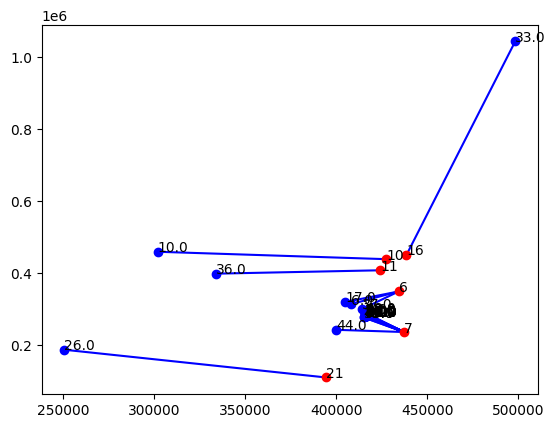

In [168]:
from pyomo.environ import *

from collections import namedtuple
import math,random
import numpy as np
from sklearn.neighbors import KDTree
import pandas as pd


Point = namedtuple("Point", ['x', 'y'])
Facility = namedtuple("Facility", ['index', 'setup_cost', 'capacity','location'])
Customer = namedtuple("Customer", ['index', 'demand','location'])

with open('./fl_25_2', 'r') as input_data_file:
            input_data = input_data_file.read()

#def solve_it(input_data):
if True:
    # Modify this code to run your optimization algorithm

    # parse the input
    lines = input_data.split('\n')

    parts = lines[0].split()
    facility_count = int(parts[0])
    customer_count = int(parts[1])

    facilities = []
    for i in range(1, facility_count+1):
        parts = lines[i].split()
        facilities.append(Facility(i-1, float(parts[0]), int(parts[1]), Point(float(parts[2]), float(parts[3])) ))

    customers = []
    for i in range(facility_count+1, facility_count+1+customer_count):
        parts = lines[i].split()
        customers.append(Customer(i-1-facility_count, int(parts[0]), Point(float(parts[1]), float(parts[2]))))

df_fac = pd.DataFrame(facilities)
df_cust= pd.DataFrame(customers)

df_cust['x'] = df_cust['location'].apply(lambda p : p.x)
df_cust['y'] = df_cust['location'].apply(lambda p : p.y)
df_fac['x'] = df_fac['location'].apply(lambda p : p.x)
df_fac['y'] = df_fac['location'].apply(lambda p : p.y)
df_fac['demand'] = 0
df_cust['assigned'] = -999



N = len(df_fac)
M = len(df_cust)
print(N,M)
P = 3
d = np.sum((np.expand_dims(df_fac[['x','y']].values,1) - np.expand_dims(df_cust[['x','y']].values,0))**2,-1)**.5



model = ConcreteModel()
model.Locations = list(range(N))
model.Customers = list(range(M))
model.x = Var( model.Locations, model.Customers,bounds=(0.0,1.0) ) #discrete, facilty,cust matrix
model.y = Var( model.Locations, within=Binary ) #facility is open/closed

model.obj = Objective( expr = sum( d[n,m]*model.x[n,m] for n in model.Locations for m in model.Customers )\
                      + sum([model.y[n]*c for n,c in zip(model.Locations,df_fac['setup_cost'])]),
                      sense=minimize )
model.single_x = ConstraintList()
for m in model.Customers:
    model.single_x.add(sum( model.x[n,m] for n in model.Locations ) == 1.0 )
model.bound_y = ConstraintList()
for n in model.Locations:
    for m in model.Customers:
        model.bound_y.add( model.x[n,m] <= model.y[n] )

for n in model.Locations:
      model.bound_y.add( sum([ d*model.x[n,m] for m,d in zip(model.Customers,df_cust['demand']) ]) <=df_fac.loc[n,'capacity'] )
#model.num_facilities = Constraint(expr=sum( model.y[n] for n in model.Locations ) == 7 )

#model.pprint()
SolverFactory('cbc', executable='/usr/bin/cbc').solve(model).write()


solution = []

for m in range(M):
    solution += [np.argmax(list(model.x[:,m]())),]
solution = np.array(solution)

for n in range(N):
    assign = np.argwhere(solution==n)[:,0]
    x_fac,y_fac = df_fac.loc[n,['x','y']]
    if len(assign)>0:
        for x,y,idx in df_cust.loc[assign,['x','y','index']].values:
            plt.plot([x,x_fac],[y,y_fac],'b')
            plt.plot([x],[y],'bo')
            plt.text(x,y,str(idx))
        plt.plot([x_fac],[y_fac],'ro')
        plt.text(x_fac,y_fac,str(n))


N,M,np.array(solution)

In [ ]:
import random

from collections import namedtuple
import math,random
import numpy as np
from sklearn.neighbors import KDTree
import pandas as pd

Point = namedtuple("Point", ['x', 'y'])
Facility = namedtuple("Facility", ['index', 'setup_cost', 'capacity','location'])
Customer = namedtuple("Customer", ['index', 'demand','location'])

with open('./fl_25_2', 'r') as input_data_file:
            input_data = input_data_file.read()

#def solve_it(input_data):
if True:
    # Modify this code to run your optimization algorithm

    # parse the input
    lines = input_data.split('\n')

    parts = lines[0].split()
    facility_count = int(parts[0])
    customer_count = int(parts[1])

    facilities = []
    for i in range(1, facility_count+1):
        parts = lines[i].split()
        facilities.append(Facility(i-1, float(parts[0]), int(parts[1]), Point(float(parts[2]), float(parts[3])) ))

    customers = []
    for i in range(facility_count+1, facility_count+1+customer_count):
        parts = lines[i].split()
        customers.append(Customer(i-1-facility_count, int(parts[0]), Point(float(parts[1]), float(parts[2]))))

df_fac = pd.DataFrame(facilities)
df_cust= pd.DataFrame(customers)

df_cust['x'] = df_cust['location'].apply(lambda p : p.x)
df_cust['y'] = df_cust['location'].apply(lambda p : p.y)
df_fac['x'] = df_fac['location'].apply(lambda p : p.x)
df_fac['y'] = df_fac['location'].apply(lambda p : p.y)
df_fac['demand'] = 0
df_cust['assigned'] = -999

df_fac0 = df_fac.copy()
df_cust0 = df_cust.copy()

chose_fac = df_fac0['index'].tolist()

def get_cost(df_cust,df_fac,chose_fac):
    cost = 0
    for i in df_fac[df_fac['demand']>0].index:
        cost += df_fac.loc[i,'setup_cost']
        df_cust_assigned_i = df_cust[df_cust['assigned']==i]
        cost += np.sum( np.sum((( df_cust[df_cust['assigned']==i][['x','y']]-df_fac.loc[i,['x','y']])**2).values,1)**.5)
    return cost


def greedy_assign(df_fac,df_cust,chose_fac,k_tree):
    df_fac['demand'] = 0
    df_cust['assigned'] = -999


    # get fac available and nearest fac to all customers
    df_fac2 = df_fac[df_fac['index'].isin(chose_fac)].reset_index(drop=1)
    if np.sum(df_fac2['capacity']) > np.sum(df_cust['demand']):
        #df_fac2 = df_fac.copy().iloc[::-1].reset_index(drop=1)
        dictt_map_sampled_dict_id = {}
        for i in df_fac2.index:
            dictt_map_sampled_dict_id[i] = df_fac2.loc[i,'index']
        tree = KDTree(df_fac2[['x','y']].iloc[:])
        nearest_fac = tree.query(df_cust[['x','y']],k=k_tree)


        # find customers which 1-3 nearest facility is far apart, means likely to do poorly if first/second choice not met
        df_cust['piority'] = (nearest_fac[0][:,2]-nearest_fac[0][:,0])*df_cust['demand']

        # greedy assign by piority
        fac_i = 0
        for i in df_cust.sort_values('piority',ascending=False).index:
            dd = df_cust.loc[i,'demand']
            for fac_i_unmap in nearest_fac[1][i]:
                fac_i = dictt_map_sampled_dict_id[fac_i_unmap]
                if  df_fac.loc[fac_i,'demand']+dd < df_fac.loc[fac_i,'capacity']:
                    df_cust.loc[i,'assigned']=fac_i
                    df_fac.loc[fac_i,'demand'] += dd
                    break
        return df_fac,df_cust

k_tree = 10
k=len(chose_fac)
prev_cost ,new_cost,best_cost = np.inf,np.inf,np.inf

chose_fac_old = chose_fac.copy()

df_fac,df_cust = greedy_assign(df_fac0,df_cust0,chose_fac,k_tree)
T0 = get_cost(df_cust,df_fac,chose_fac)/len(df_cust)

for iteration in range(300):
    T = T0 * 0.9**iteration

    k=len(chose_fac_old )
    prob = np.random.uniform(0,1)
    random.shuffle(chose_fac_old )
    if prob <= 1/3 or k == len(df_fac):
        chose_fac =  chose_fac_old [1:].copy()
    elif prob <= 2/3:
        chose_fac = chose_fac_old [1:].copy() + df_fac[~df_fac['index'].isin(chose_fac)]['index'].sample(n=1).tolist()
    else :
        chose_fac = chose_fac_old [:].copy() + df_fac[~df_fac['index'].isin(chose_fac)]['index'].sample(n=1).tolist()

    #print(len(chose_fac))
    try:
        df_fac,df_cust = greedy_assign(df_fac0,df_cust0,chose_fac,k_tree)
    except :
        None
    if len(df_cust[df_cust['assigned']==-999]) >0:
        k_tree += 1
        print(k)
    else:
        new_cost = get_cost(df_cust,df_fac,chose_fac)
        if np.exp(-(new_cost - prev_cost)/T) >  np.random.uniform(0,1) :
            prev_cost = new_cost
            chose_fac_old = chose_fac.copy()
            if new_cost < best_cost:
                best_cost = new_cost
                best_result = (df_fac.copy(),df_cust.copy())

        if iteration%100 == 1:
            print (iteration,new_cost,best_cost,len(chose_fac),T,sorted(chose_fac),)




# this is for baseline, check if obj calcualtion is correct
# for i in df_cust.index:
#     dd = df_cust.loc[i,'demand']
#     for fac_i in range(max(df_cust.loc[max(0,i-1),'assigned'],0),17):#nearest_fac[1][i]:
#         if fac_i not in full and df_fac.loc[fac_i,'demand']+dd < df_fac.loc[fac_i,'capacity']:
#             df_cust.loc[i,'assigned']=fac_i
#             df_fac.loc[fac_i,'demand'] += dd
#             break




display(df_fac.head(),df_cust.head())

1 3276471.4003415485 3276471.4003415485 25 58976.485206147874 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
22
101 3269821.3205308826 3269821.3205308826 23 1.5664979485483992 [0, 1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


ValueError: a must be greater than 0 unless no samples are taken

In [ ]:
best_result[1].assigned.values


#10
[ 7,  7,  7,  7,  7,  7,  6,  7,  7,  7, 10,  7,  7,  7,  7,  7,  7,
        6,  7,  7,  7,  7,  7,  7,  7,  7, 21,  7,  7,  7,  7,  7,  7, 16,
        7,  7, 11,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7]

#7
[28, 24, 19, 25, 14, 15, 34,  3,  9, 24, 35, 42, 41, 24, 49,  3, 16,
       26, 43, 22, 45, 41,  9, 34,  9, 13, 19,  9, 38, 24, 24,  7,  9, 25,
       31, 33, 28,  9, 28, 25, 38, 40, 35,  7,  2, 23, 40, 25, 41,  9, 34,
       44, 41, 18, 35,  5,  9, 31, 14, 35, 31, 13, 44, 43,  9,  4,  8, 14,
       25, 45, 28, 33, 41, 39, 46,  6,  8, 35,  6, 24, 40, 47, 31, 24, 31,
       24, 24, 45, 34, 16,  7,  2,  5, 39, 25, 35, 24, 40, 31,  3, 47,  6,
       39, 16, 31, 44,  2, 16,  9, 13,  8, 16, 47, 35, 15, 24, 43, 25, 46,
       16, 35, 28, 34, 35, 13,  5,  8, 35, 18, 11, 38, 39, 43, 41, 47, 44,
        9, 41,  9, 38, 38, 28, 23,  9, 28, 28, 42, 41, 47, 16, 35, 38, 29,
        9, 45, 49, 16, 25, 26, 31, 38,  5, 49, 10,  7, 40, 44, 29, 34, 10,
        2, 41, 35, 31, 40, 28, 35, 49, 44, 33,  4,  2, 16, 47, 28,  9,  3,
       31, 11, 16, 31, 25, 21, 42, 13, 31,  8, 40, 44, 45]
#
[70, 70, 65, 89, 70, 70, 16, 16, 70, 70, 70, 70, 70, 65, 65, 70, 16,
       65, 16, 16, 16, 70, 70, 16, 70, 70, 70, 70, 70, 16, 70, 70, 70, 16,
       70, 70, 89, 16, 70, 16, 70, 65, 70, 65, 16, 89, 70, 70, 70, 70, 16,
       70, 70, 16, 70, 16, 70, 70, 70, 16, 70, 65, 70, 86, 16, 70, 70, 70,
       70, 16, 70, 70, 70, 70, 70, 65, 70, 16, 70, 70, 70, 70, 70, 16, 70,
       65, 70, 70, 70, 16, 16, 65, 70, 65, 70, 16, 16, 16, 70, 70]

np.array(list(map(int,'''70 70 65 89 70 70 16 16 70 70 70 70 70 65 65 70 16 65 16 16 16 70 70 16 70 70 70 70 70 16 70 70 70 16 70 70 89 16 70 16 70 65 70 65 16 89 70 70 70 70 16 70 70 16 70 16 70 70 70 16 70 65 70 86 16 70 70 70 70 16 70 70 70 70 70 65 70 16 70 70 70 70 70 16 70 65 70 70 70 16 16 65 70 65 70 16 16 16 70 70'''.split())))

array([70, 70, 65, 89, 70, 70, 16, 16, 70, 70, 70, 70, 70, 65, 65, 70, 16,
       65, 16, 16, 16, 70, 70, 16, 70, 70, 70, 70, 70, 16, 70, 70, 70, 16,
       70, 70, 89, 16, 70, 16, 70, 65, 70, 65, 16, 89, 70, 70, 70, 70, 16,
       70, 70, 16, 70, 16, 70, 70, 70, 16, 70, 65, 70, 86, 16, 70, 70, 70,
       70, 16, 70, 70, 70, 70, 70, 65, 70, 16, 70, 70, 70, 70, 70, 16, 70,
       65, 70, 70, 70, 16, 16, 65, 70, 65, 70, 16, 16, 16, 70, 70])

In [ ]:
df_fac[~df_fac['index'].isin(chose_fac)]['index']#.sample(n=1).tolist()

,index


In [ ]:
df_fac[~df_fac['index'].isin(chose_fac)]

,index,setup_cost,capacity,location,x,y,demand
3,3,8448.5819,5016,"(132462.04, 198056.1075)",132462.0400,198056.1075,0
11,11,8550.8948,5699,"(89937.4575, 145752.555)",89937.4575,145752.5550,0
29,29,9041.5207,5043,"(91396.095, 86844.7425)",91396.0950,86844.7425,0
40,40,7534.8257,5958,"(60466.48, 37621.3975)",60466.4800,37621.3975,0


In [ ]:
df_cust[df_cust['assigned']==-999]

,index,demand,location,x,y,assigned,piority


In [ ]:
get_cost(df_cust,df_fac)#/20216201.25,df_cust.assigned.values

3871558.9441835857

In [ ]:
get_cost(df_cust,df_fac2)

df_cust.assigned.values

array([28, 24,  2, 25, 14, 48, 34,  3, 48, 24, 41, 42, 41, 24, 49,  3, 48,
       14, 43,  0,  0, 41,  0, 34, 48, 41,  2,  6, 20, 24, 24,  7, 31, 20,
       31, 33, 28,  0, 28, 25, 32, 40, 41,  7,  2, 37, 27, 25, 41,  0, 34,
        3, 11, 20, 47,  5,  0, 48, 14, 47, 31, 47,  5, 43, 48,  4,  7, 14,
       25,  0, 43, 33, 41, 40, 42,  6,  7, 47,  6, 24, 40,  2, 31, 24, 31,
       24, 24,  0, 34, 31,  7,  2,  5, 40, 20, 47, 24, 40, 31,  3, 47,  6,
       34, 48, 31, 11,  2, 48, 48, 41,  7, 48, 47, 47,  5, 24, 43, 25, 42,
       48, 41, 28, 34, 47, 11,  5, 28, 47, 33, 11, 32, 34, 43, 41, 47, 11,
       48, 41, 48, 32, 20, 28, 37,  0, 14, 28, 42, 41, 47, 31, 41, 32, 14,
       14,  0, 49, 48, 20, 34, 31, 32,  5, 49, 49,  7, 27,  3, 24, 34, 49,
        2, 41, 11, 31, 40, 28, 41, 49, 48, 33,  4,  2, 31, 47, 28,  0,  3,
       31, 11, 48, 31, 25,  5, 42, 11, 31, 28, 40,  3, 14])

In [ ]:
df_cust['demand_score'] = (df_cust['demand']-np.mean(df_cust['demand']))/np.std(df_cust['demand'])

display(df_cust.iloc[147:151],df_fac.loc[nearest_fac[1][149]])

,index,demand,location,x,y,assigned,piority,demand_score
147,147,343,"(72229.495, 132858.305)",72229.4950,132858.3050,41,4.368195e+06,-0.648814
148,148,474,"(47212.7, 136032.3925)",47212.7000,136032.3925,47,1.412472e+07,0.867052
149,149,281,"(197439.155, 113112.865)",197439.1550,113112.8650,31,4.764111e+06,-1.366247
150,150,547,"(57551.3125, 183169.675)",57551.3125,183169.6750,41,7.308426e+06,1.711772


,index,setup_cost,capacity,location,x,y,demand
17,17,9233.8784,5426,"(145388.37, 39997.8125)",145388.3700,39997.8125,0
3,3,8448.5819,5016,"(132462.04, 198056.1075)",132462.0400,198056.1075,3037
8,8,9711.6038,5702,"(176469.0075, 63000.005)",176469.0075,63000.0050,0
16,16,8279.3467,5190,"(149540.8075, 132840.93)",149540.8075,132840.9300,0
2,2,9211.2124,5543,"(13670.385, 88631.495)",13670.3850,88631.4950,3112
25,25,8350.3181,5352,"(38046.2775, 33185.755)",38046.2775,33185.7550,2760
19,19,6912.1270,6794,"(44955.9025, 103012.8725)",44955.9025,103012.8725,0
21,21,8726.1958,4992,"(124526.135, 119835.265)",124526.1350,119835.2650,0
5,5,8264.8269,4775,"(123240.4925, 125211.0)",123240.4925,125211.0000,3161
0,0,9730.3749,4765,"(128659.9725, 95787.725)",128659.9725,95787.7250,4735


,index,demand,location,x,y,assigned,piority
0,0,270,"(155605.3725, 39123.8675)",155605.3725,39123.8675,17,5.565762e+06
1,1,265,"(79566.37, 87796.535)",79566.3700,87796.5350,24,2.522688e+06
2,2,427,"(19535.84, 130369.4225)",19535.8400,130369.4225,19,1.118073e+06
3,3,394,"(31568.01, 7981.3775)",31568.0100,7981.3775,25,5.634931e+06
4,4,369,"(133210.275, 67275.5275)",133210.2750,67275.5275,14,2.553776e+06
...,...,...,...,...,...,...,...
195,195,340,"(174048.9425, 161392.5725)",174048.9425,161392.5725,31,8.345309e+06
196,196,521,"(195197.675, 58734.08)",195197.6750,58734.0800,8,1.733260e+07
197,197,390,"(64409.25, 39565.745)",64409.2500,39565.7450,40,7.200588e+06
198,198,436,"(133994.605, 170537.9225)",133994.6050,170537.9225,44,3.918649e+06


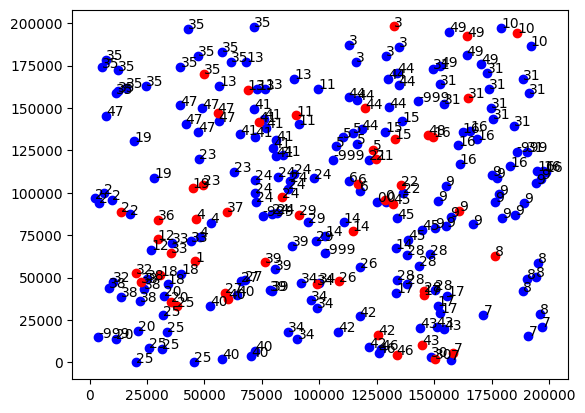

In [ ]:
import matplotlib.pyplot as plt

for x,y,idx in df_cust[['x','y','new']].values:
    idx = int(idx)
    plt.plot(x,y,'bo')
    plt.text(x,y,str(idx))


for x,y,idx in df_fac[df_fac['index'].isin(chose_fac)][['x','y','index']].values:
    idx = int(idx)
    plt.plot(x,y,'ro')
    plt.text(x,y,str(idx))

In [ ]:
nearest_fac[1][149],nearest_fac_score[149,:]

(array([ 9, 16, 31, 48,  8]),
 array([3.40945095, 4.43944587, 4.71606627, 4.7390084 , 4.76064764]))

In [ ]:
np.argsort(-nearest_fac_score[:,0])

array([149,  50, 111,  33,  42, 163,  89, 176, 165, 114,  20, 188, 182,
        38,  65, 118, 164, 185,  32, 140, 157, 133, 122,  77,  37, 174,
        62,  87,  61,  23, 110,  55, 194, 193,  67, 151, 125, 112, 160,
       119, 105,  36,  22,  35, 135, 172,  70, 132, 131, 158, 168,   8,
       146, 150, 191,  69,  44, 141,  10, 148,  66,  29,  82,  41,  68,
       128, 130, 154,  86,  91, 142,   4, 136, 144, 101,  24,   7,  26,
       145,  12,  11, 183,  49, 199, 139,  56, 129,   3,  48,  75,  17,
       115,  73,  34,  45, 100, 161,  25,  99,  21, 152, 107, 126, 166,
        60, 153,  93, 192,  96, 127, 138, 169,  47, 103,  57, 143, 104,
        46, 171, 177,   9,  79, 121, 155, 197,  92,  19,  71, 180,  74,
       106, 186, 170,  52, 156,  40, 102, 134,  13, 179,  51, 196, 198,
        28,  63, 184,  95, 124, 195,  85,  53, 116, 173, 147,   6,  88,
        90, 108, 187, 159,  84, 181,   2,  94, 123, 175, 162,  14,  58,
        18,  98,  72, 120,  30,  54, 178,  27,  31,  16,   0, 16

In [ ]:
tree = KDTree(df_cust[['x','y']])

In [ ]:
# Facility

#!/usr/bin/python
# -*- coding: utf-8 -*-

from collections import namedtuple
import math,random
import numpy as np
from sklearn.neighbors import KDTree
import pandas as pd

Point = namedtuple("Point", ['x', 'y'])
Facility = namedtuple("Facility", ['index', 'setup_cost', 'capacity','location'])
Customer = namedtuple("Customer", ['index', 'demand','location'])

def length(point1, point2):
    return math.sqrt((point1.x - point2.x)**2 + (point1.y - point2.y)**2)

with open('./fl_50_6', 'r') as input_data_file:
            input_data = input_data_file.read()

#def solve_it(input_data):
if True:
    # Modify this code to run your optimization algorithm

    # parse the input
    lines = input_data.split('\n')

    parts = lines[0].split()
    facility_count = int(parts[0])
    customer_count = int(parts[1])

    facilities = []
    for i in range(1, facility_count+1):
        parts = lines[i].split()
        facilities.append(Facility(i-1, float(parts[0]), int(parts[1]), Point(float(parts[2]), float(parts[3])) ))

    customers = []
    for i in range(facility_count+1, facility_count+1+customer_count):
        parts = lines[i].split()
        customers.append(Customer(i-1-facility_count, int(parts[0]), Point(float(parts[1]), float(parts[2]))))

    # build a trivial solution
    # pack the facilities one by one until all the customers are served
    solution = [-1]*len(customers)
    capacity_remaining = [f.capacity for f in facilities]

    facility_index = 0
    for customer in customers:
        if capacity_remaining[facility_index] >= customer.demand:
            solution[customer.index] = facility_index
            capacity_remaining[facility_index] -= customer.demand
        else:
            facility_index += 1
            assert capacity_remaining[facility_index] >= customer.demand
            solution[customer.index] = facility_index
            capacity_remaining[facility_index] -= customer.demand

    used = [0]*len(facilities)
    for facility_index in solution:
        used[facility_index] = 1

    # calculate the cost of the solution
    obj = sum([f.setup_cost*used[f.index] for f in facilities])
    for customer in customers:
        obj += length(customer.location, facilities[solution[customer.index]].location)

    # prepare the solution in the specified output format
    output_data = '%.2f' % obj + ' ' + str(0) + '\n'
    output_data += ' '.join(map(str, solution))
    print (output_data)
    #return output_data





FileNotFoundError: [Errno 2] No such file or directory: './fl_50_6'

In [ ]:
'''

structure of a point
- x
- y
- id
- neighbours (must be 2 & symetrical )

1. for each point, get the closest ~50 neigbours
2. for each point, get criss-cross edges
'''


import random
import numpy as np
from collections import namedtuple
import matplotlib.pyplot as plt

Point = namedtuple("Point", ['x', 'y'])

def length(point1, point2):
    return np.sqrt((point1.x - point2.x)**2 + (point1.y - point2.y)**2)

with open('./tsp_51_1', 'r') as input_data_file:
    input_data = input_data_file.read()




def get_score(d):
    r = [x[2] for x in d]
    return np.sum(r)

In [ ]:
if True:
    lines = input_data.split('\n')

    nodeCount = int(lines[0])

    points = []
    for i in range(1, nodeCount+1):
        line = lines[i]
        parts = line.split()
        points.append(Point(float(parts[0]), float(parts[1])))
    # print(points)
    D = {}
    # build a trivial solution
    # visit the nodes in the order they appear in the file

    solution = list(range(len(points)))
    random.shuffle(solution)

    solution_edge = []
    for i in range(0,len(solution)-1):
        solution_edge += [(solution[i],solution[i+1],
                           length(points[solution[i]],points[solution[i+1]]))]
    solution_edge+= [(solution[i+1],solution[0],
                      length(points[solution[i]],points[solution[0]])),]
    print(get_score(solution_edge))
    best_result = solution_edge.copy()
    if nodeCount <=600:
        for attempt in range(10):
            solution_edge = best_result.copy()
            best_score = get_score(best_result)
            current_score = get_score(solution_edge)
            print(best_score,current_score)
            T0 = get_score(solution_edge)/len(best_result)
            iteration = 0
            sucess = 1
            while iteration <=3000000  or sucess >= 0.05:
                T = T0*0.999998**np.abs(iteration)
                iteration += 1
                #get crisscross edges, to not do all the tiume for faster speed
                for k in range(2,3):#def k_opt(solution_edge,points,obj):
                    edge_i = np.random.choice(range(len(solution_edge)))

                    x1 = solution_edge[edge_i][0]
                    x2 = solution_edge[edge_i][1]

                    for edge_j in np.random.choice(range(len(solution_edge)),size=6):
                        x3 = solution_edge[edge_j][0]
                        x4 = solution_edge[edge_j][1]
                        if x4 not in [x1,x2] and x3 not in [x1,x2]:
                            break
                    if edge_i > edge_j:
                        edge_i,edge_j = edge_j,edge_i
                        x1 = solution_edge[edge_i][0]
                        x2 = solution_edge[edge_i][1]
                        x3 = solution_edge[edge_j][0]
                        x4 = solution_edge[edge_j][1]


                    newedge_x1x3 = (x1,x3,length(points[x1],points[x3]))
                    newedge_x2x4 = (x2,x4,length(points[x2],points[x4]))

                    score = -solution_edge[edge_i][2] - solution_edge[edge_j][2]
                    score += newedge_x1x3[2] + newedge_x2x4[2]

                    if np.exp(-score/T) > np.random.uniform(0,1) :
                        current_score += score
                        sucess  = 0.995*sucess + 0.001
                        solution_edge[edge_i] = newedge_x1x3
                        solution_edge[edge_j] = newedge_x2x4

                        earlier_edge = min(edge_i,edge_j)
                        laster_edge = max(edge_i,edge_j)
                        temp = []
                        for edge_k in range(earlier_edge+1,laster_edge):
                            a,b,c = solution_edge[edge_k]
                            temp += [(b,a,c),]
                        for edge_k in range(earlier_edge+1,laster_edge):
                            solution_edge[edge_k] = tuple(temp.pop())

                        if best_score > current_score:
                                die
                                best_result = solution_edge.copy()
                                best_score = get_score(best_result)


                    else:
                        sucess  = 0.995*sucess

                    if iteration%10000==0:
                        print(attempt,iteration,get_score(solution_edge),T)

                # reorder wrongly directed edges


    solution = []
    for i in solution_edge:
        solution += [i[0],]

    # calculate the length of the tour
    obj = []
    for index in range(0, nodeCount-1):
        obj += [length(points[solution[index]], points[solution[index+1]]),]
    obj += [length(points[solution[-1]], points[solution[0]]),]
    print (obj)

    # prepare the solution in the specified output format
    output_data = '%.2f' % np.sum(obj) + ' ' + str(0) + '\n'
    output_data += ' '.join(map(str, solution))
    print(output_data)

1609.7668970637174
1609.7668970637174 1609.7668970637174


NameError: name 'die' is not defined

In [ ]:
get_score(best_result),get_score(solution_edge)

(1609.7668970637174, 1623.4038345357692)

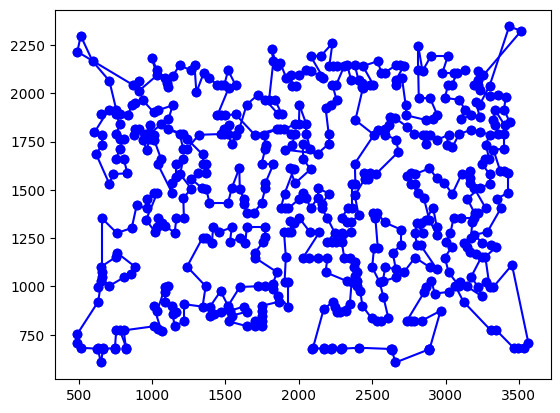

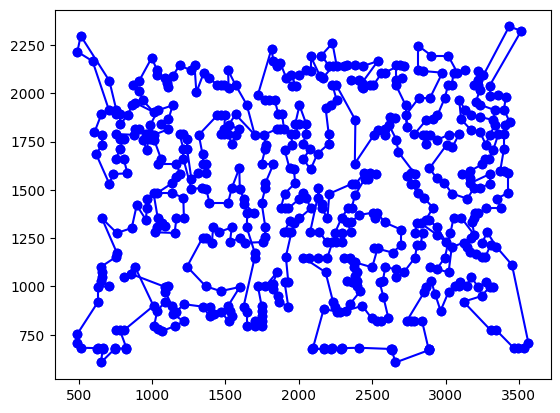

In [ ]:
for i in solution_edge:
    a,b,c = i
    points_xy = points.copy()
    plt.plot([points_xy[a].x,points_xy[b].x],[points_xy[a].y,points_xy[b].y],'bo')
    plt.plot([points_xy[a].x,points_xy[b].x],[points_xy[a].y,points_xy[b].y],'b')
    #plt.text(points_xy[a].x,points_xy[a].y,str(a))
    #plt.text(points_xy[b].x,points_xy[b].y,str(b))
plt.show()


for i in best_result:
    a,b,c = i
    points_xy = points.copy()
    plt.plot([points_xy[a].x,points_xy[b].x],[points_xy[a].y,points_xy[b].y],'bo')
    plt.plot([points_xy[a].x,points_xy[b].x],[points_xy[a].y,points_xy[b].y],'b')
    #plt.text(points_xy[a].x,points_xy[a].y,str(a))
    #plt.text(points_xy[b].x,points_xy[b].y,str(b))
plt.show()